In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from tqdm import tqdm

pd.set_option('display.max_columns', 100)

-------------

LOADING THE FEATURE DATASET AND SETTING IT UP

----------

In [2]:
features_df = pd.read_parquet("/Users/sudhanvabharadwaj/Documents/Full_Quant_Pipeline/Data/processed/splits/train.parquet")
features_df.head()

,date,ticker,fwd_return_5d,dollar_volume,price_ma_ratio_5,price_ma_ratio_10,price_ma_ratio_21,price_ma_ratio_63,price_ma_ratio_252,pos_days_21,z_price_21,z_price_63,z_return_1d_5,z_return_1d_21,z_return_1d_35,z_return_5d_5,z_return_5d_21,z_return_5d_35,rev_1d,rev_5d,vol_5,vol_10,vol_21,vol_63,vol_ratio_21_63,vol_ratio_5_21,hl_range,downside_vol_1d,downside_vol_5d,vol_avg_5,vol_avg_21,vol_avg_63,dollar_vol_log,volume_trend,mom_x_vol_5,mom_x_vol_21,mom_x_vol_63,dollar_volume_rank,price_ma_ratio_5_rank,price_ma_ratio_10_rank,price_ma_ratio_21_rank,price_ma_ratio_63_rank,price_ma_ratio_252_rank,pos_days_21_rank,z_price_21_rank,z_price_63_rank,z_return_1d_5_rank,z_return_1d_21_rank,z_return_1d_35_rank,z_return_5d_5_rank,z_return_5d_21_rank,z_return_5d_35_rank,rev_1d_rank,rev_5d_rank,vol_5_rank,vol_10_rank,vol_21_rank,vol_63_rank,vol_ratio_21_63_rank,vol_ratio_5_21_rank,hl_range_rank,downside_vol_1d_rank,downside_vol_5d_rank,vol_avg_5_rank,vol_avg_21_rank,vol_avg_63_rank,dollar_vol_log_rank,volume_trend_rank,mom_x_vol_5_rank,mom_x_vol_21_rank,mom_x_vol_63_rank
0,2011-01-03,AAPL,0.039081,4.399815e+09,0.013095,0.015186,0.022646,0.053737,0.266111,0.571429,3.219192,1.933459,6.205207,4.556801,1.968330,1.473465,1.188747,0.563274,-0.021733,-0.015062,0.010828,0.007771,0.006388,0.012496,0.511151,1.695154,0.016446,0.002118,0.001247,227040800.0,3.092279e+08,4.488507e+08,22.204828,-8.312502e+06,3.419588e+06,1.109984e+07,8.204138e+07,1.000000,0.736842,0.710526,0.605263,0.500000,0.864865,0.500000,0.973684,0.763158,0.894737,0.973684,0.789474,0.631579,0.894737,0.710526,0.263158,0.368421,0.657895,0.526316,0.263158,0.500000,0.105263,0.973684,0.552632,0.078947,0.105263,0.947368,0.947368,0.973684,1.000000,0.078947,0.947368,0.947368,0.973684
1,2011-01-04,AAPL,0.031242,3.070944e+09,0.014752,0.017638,0.025883,0.056965,0.270454,0.619048,3.176819,2.064851,0.201146,0.550862,0.353519,1.623876,1.537063,0.668571,-0.005219,-0.017882,0.010860,0.007778,0.006365,0.011709,0.543587,1.706237,0.013131,0.002138,0.001247,253672160.0,3.076559e+08,4.457890e+08,21.845251,-7.844913e+06,4.536055e+06,1.342301e+07,6.533927e+07,1.000000,0.710526,0.684211,0.605263,0.473684,0.891892,0.710526,0.921053,0.789474,0.631579,0.684211,0.657895,0.763158,0.868421,0.578947,0.368421,0.447368,0.631579,0.421053,0.236842,0.421053,0.105263,0.947368,0.368421,0.052632,0.105263,0.947368,0.947368,0.973684,1.000000,0.078947,0.947368,0.947368,0.947368
2,2011-01-05,AAPL,0.031198,2.559542e+09,0.017622,0.022883,0.032167,0.063198,0.278453,0.619048,3.415721,2.299103,0.421924,0.962302,0.591080,2.039551,2.618641,1.059896,-0.008180,-0.026776,0.010727,0.007900,0.006347,0.011732,0.541041,1.690040,0.014491,0.002138,0.001247,272148240.0,2.984672e+08,4.391961e+08,21.663094,-6.510211e+06,7.287014e+06,1.291194e+07,6.805336e+07,0.973684,0.710526,0.684211,0.684211,0.578947,0.891892,0.644737,0.894737,0.789474,0.684211,0.815789,0.736842,0.763158,0.921053,0.684211,0.342105,0.315789,0.526316,0.473684,0.236842,0.421053,0.105263,0.947368,0.315789,0.078947,0.078947,0.947368,0.947368,0.973684,0.973684,0.078947,0.947368,0.947368,0.947368
3,2011-01-06,AAPL,0.035807,3.006965e+09,0.010599,0.019381,0.028983,0.059955,0.275035,0.619048,2.552165,2.073033,-0.573526,-0.448357,-0.319067,1.507628,2.701934,1.245121,0.000808,-0.031113,0.009841,0.007992,0.006112,0.011735,0.520783,1.610264,0.007042,0.001858,0.001247,300735120.0,2.941327e+08,4.374823e+08,21.824197,-5.156353e+06,9.356793e+06,1.434567e+07,6.732704e+07,1.000000,0.578947,0.631579,0.631579,0.578947,0.837838,0.657895,0.789474,0.684211,0.342105,0.421053,0.473684,0.736842,0.947368,0.763158,0.500000,0.368421,0.473684,0.447368,0.184211,0.421053,0.105263,0.947368,0.052632,0.052632,0.052632,0.947368,0.947368,0.973684,1.000000,0.052632,0.947368,0.947368,0.947368
4,2011-01-07,AAPL,0.036773,3.144450e+09,0.009545,0.022770,0.034058,0.065287,0.281753,0.619048,2.711839,2.221146,0.099208,0.797406,0.437819,1.844606,3.590129,1.875910,-0.007161,-0.042039,0.008280,0.007643,0.006034,0.011606,0.519904,

In [3]:
features_df.shape

(109284, 71)

In [4]:
features_df.reset_index(drop=True, inplace=True)

In [5]:
features_df.shape

(109284, 71)

In [6]:
features_df.head()

,date,ticker,fwd_return_5d,dollar_volume,price_ma_ratio_5,price_ma_ratio_10,price_ma_ratio_21,price_ma_ratio_63,price_ma_ratio_252,pos_days_21,z_price_21,z_price_63,z_return_1d_5,z_return_1d_21,z_return_1d_35,z_return_5d_5,z_return_5d_21,z_return_5d_35,rev_1d,rev_5d,vol_5,vol_10,vol_21,vol_63,vol_ratio_21_63,vol_ratio_5_21,hl_range,downside_vol_1d,downside_vol_5d,vol_avg_5,vol_avg_21,vol_avg_63,dollar_vol_log,volume_trend,mom_x_vol_5,mom_x_vol_21,mom_x_vol_63,dollar_volume_rank,price_ma_ratio_5_rank,price_ma_ratio_10_rank,price_ma_ratio_21_rank,price_ma_ratio_63_rank,price_ma_ratio_252_rank,pos_days_21_rank,z_price_21_rank,z_price_63_rank,z_return_1d_5_rank,z_return_1d_21_rank,z_return_1d_35_rank,z_return_5d_5_rank,z_return_5d_21_rank,z_return_5d_35_rank,rev_1d_rank,rev_5d_rank,vol_5_rank,vol_10_rank,vol_21_rank,vol_63_rank,vol_ratio_21_63_rank,vol_ratio_5_21_rank,hl_range_rank,downside_vol_1d_rank,downside_vol_5d_rank,vol_avg_5_rank,vol_avg_21_rank,vol_avg_63_rank,dollar_vol_log_rank,volume_trend_rank,mom_x_vol_5_rank,mom_x_vol_21_rank,mom_x_vol_63_rank
0,2011-01-03,AAPL,0.039081,4.399815e+09,0.013095,0.015186,0.022646,0.053737,0.266111,0.571429,3.219192,1.933459,6.205207,4.556801,1.968330,1.473465,1.188747,0.563274,-0.021733,-0.015062,0.010828,0.007771,0.006388,0.012496,0.511151,1.695154,0.016446,0.002118,0.001247,227040800.0,3.092279e+08,4.488507e+08,22.204828,-8.312502e+06,3.419588e+06,1.109984e+07,8.204138e+07,1.000000,0.736842,0.710526,0.605263,0.500000,0.864865,0.500000,0.973684,0.763158,0.894737,0.973684,0.789474,0.631579,0.894737,0.710526,0.263158,0.368421,0.657895,0.526316,0.263158,0.500000,0.105263,0.973684,0.552632,0.078947,0.105263,0.947368,0.947368,0.973684,1.000000,0.078947,0.947368,0.947368,0.973684
1,2011-01-04,AAPL,0.031242,3.070944e+09,0.014752,0.017638,0.025883,0.056965,0.270454,0.619048,3.176819,2.064851,0.201146,0.550862,0.353519,1.623876,1.537063,0.668571,-0.005219,-0.017882,0.010860,0.007778,0.006365,0.011709,0.543587,1.706237,0.013131,0.002138,0.001247,253672160.0,3.076559e+08,4.457890e+08,21.845251,-7.844913e+06,4.536055e+06,1.342301e+07,6.533927e+07,1.000000,0.710526,0.684211,0.605263,0.473684,0.891892,0.710526,0.921053,0.789474,0.631579,0.684211,0.657895,0.763158,0.868421,0.578947,0.368421,0.447368,0.631579,0.421053,0.236842,0.421053,0.105263,0.947368,0.368421,0.052632,0.105263,0.947368,0.947368,0.973684,1.000000,0.078947,0.947368,0.947368,0.947368
2,2011-01-05,AAPL,0.031198,2.559542e+09,0.017622,0.022883,0.032167,0.063198,0.278453,0.619048,3.415721,2.299103,0.421924,0.962302,0.591080,2.039551,2.618641,1.059896,-0.008180,-0.026776,0.010727,0.007900,0.006347,0.011732,0.541041,1.690040,0.014491,0.002138,0.001247,272148240.0,2.984672e+08,4.391961e+08,21.663094,-6.510211e+06,7.287014e+06,1.291194e+07,6.805336e+07,0.973684,0.710526,0.684211,0.684211,0.578947,0.891892,0.644737,0.894737,0.789474,0.684211,0.815789,0.736842,0.763158,0.921053,0.684211,0.342105,0.315789,0.526316,0.473684,0.236842,0.421053,0.105263,0.947368,0.315789,0.078947,0.078947,0.947368,0.947368,0.973684,0.973684,0.078947,0.947368,0.947368,0.947368
3,2011-01-06,AAPL,0.035807,3.006965e+09,0.010599,0.019381,0.028983,0.059955,0.275035,0.619048,2.552165,2.073033,-0.573526,-0.448357,-0.319067,1.507628,2.701934,1.245121,0.000808,-0.031113,0.009841,0.007992,0.006112,0.011735,0.520783,1.610264,0.007042,0.001858,0.001247,300735120.0,2.941327e+08,4.374823e+08,21.824197,-5.156353e+06,9.356793e+06,1.434567e+07,6.732704e+07,1.000000,0.578947,0.631579,0.631579,0.578947,0.837838,0.657895,0.789474,0.684211,0.342105,0.421053,0.473684,0.736842,0.947368,0.763158,0.500000,0.368421,0.473684,0.447368,0.184211,0.421053,0.105263,0.947368,0.052632,0.052632,0.052632,0.947368,0.947368,0.973684,1.000000,0.052632,0.947368,0.947368,0.947368
4,2011-01-07,AAPL,0.036773,3.144450e+09,0.009545,0.022770,0.034058,0.065287,0.281753,0.619048,2.711839,2.221146,0.099208,0.797406,0.437819,1.844606,3.590129,1.875910,-0.007161,-0.042039,0.008280,0.007643,0.006034,0.011606,0.519904,

-------------

ISOLATION

->Isolating the feature columns by removing date, ticker, fwd_ret

->Also removing rank features as spearman on ranked version of the feature or the feature itself leads to same value

-----------

In [7]:
rank_cols = [col for col in features_df.columns if '_rank' in col]
df2 = features_df.drop(columns=rank_cols)

In [8]:
cols = ["date", "ticker", "fwd_return_5d"]

feature_cols = [c for c in df2.columns if c not in cols]

len(feature_cols)

34

-----------------

Info. Coefficient Function

------------

In [9]:
def compute_daily_ic(df, feature_cols, return_col="fwd_return_5d"):
    ic_records = []

    grouped = df.groupby("date")

    for date, g in tqdm(grouped, total=len(grouped)):
        if g.shape[0] < 30:
            continue 

        for col in feature_cols:
            x = g[col]
            y = g[return_col]

            if x.isna().all():
                continue

            ic, _ = spearmanr(x, y, nan_policy='omit')

            ic_records.append({
                "date": date,
                "feature": col,
                "ic": ic
            })

    return pd.DataFrame(ic_records)


In [10]:
ic_df = compute_daily_ic(df2, feature_cols)
ic_df.head()

100%|██████████| 2769/2769 [00:18<00:00, 147.39it/s]


,date,feature,ic
0,2011-01-03,dollar_volume,0.056899
1,2011-01-03,price_ma_ratio_5,0.306069
2,2011-01-03,price_ma_ratio_10,0.307492
3,2011-01-03,price_ma_ratio_21,0.206970
4,2011-01-03,price_ma_ratio_63,0.184211


-------

Information Coefficient Module

In [11]:
ic_df.shape

(94146, 3)

In [12]:
cols = ['date','ic', 'feature']
ic_df[cols].sort_values(by = 'ic', ascending=False).head(20)

,date,ic,feature
78769,2020-03-18,0.886492,downside_vol_5d
79259,2020-04-08,0.875047,price_ma_ratio_252
78803,2020-03-19,0.858912,downside_vol_5d
78802,2020-03-19,0.845591,downside_vol_1d
78760,2020-03-18,0.839962,rev_5d
5456,2011-08-22,0.838276,rev_5d
78768,2020-03-18,0.835835,downside_vol_1d
78837,2020-03-20,0.818011,downside_vol_5d
80857,2020-06-16,0.809381,price_ma_ratio_252
5460,2011-08-22,0.809169,vol_63


--------

Aggregating IC stats

-----------

In [13]:
ic_summary = (ic_df.groupby("feature")['ic'].agg(['mean', 'std', 'count']).reset_index())
ic_summary

,feature,mean,std,count
0,dollar_vol_log,-0.003609,0.218123,2769
1,dollar_volume,-0.003609,0.218123,2769
2,downside_vol_1d,0.017557,0.285499,2769
3,downside_vol_5d,0.015319,0.269147,2769
4,hl_range,0.020819,0.257480,2769
5,mom_x_vol_21,0.009903,0.224877,2769
6,mom_x_vol_5,-0.010037,0.227501,2769
7,mom_x_vol_63,0.004928,0.241299,2769
8,pos_days_21,0.000582,0.202812,2769
9,price_ma_ratio_10,-0.017613,0.235132,2769


In [14]:
cols = ['mean', 'feature']
ic_summary[cols].sort_values(by = 'mean', ascending=False).head(20)

,mean,feature
16,0.027638,vol_10
19,0.027087,vol_63
17,0.026445,vol_21
18,0.024596,vol_5
4,0.020819,hl_range
2,0.017557,downside_vol_1d
15,0.016885,rev_5d
14,0.015826,rev_1d
3,0.015319,downside_vol_5d
22,0.012590,vol_avg_63


In [15]:
ic_summary["t_stat"] = (
    ic_summary["mean"] / 
    (ic_summary["std"] / np.sqrt(ic_summary["count"]))
)

ic_summary["IR"] = ic_summary["mean"] / ic_summary["std"]

ic_summary.sort_values("t_stat", ascending=False).head(10)

,feature,mean,std,count,t_stat,IR
16,vol_10,0.027638,0.276673,2769,5.256460,0.099892
18,vol_5,0.024596,0.258240,2769,5.011944,0.095246
17,vol_21,0.026445,0.295626,2769,4.707264,0.089456
19,vol_63,0.027087,0.312613,2769,4.559482,0.086647
4,hl_range,0.020819,0.257480,2769,4.254799,0.080857
15,rev_5d,0.016885,0.233354,2769,3.807562,0.072358
14,rev_1d,0.015826,0.234857,2769,3.545916,0.067386
2,downside_vol_1d,0.017557,0.285499,2769,3.236018,0.061496
22,vol_avg_63,0.012590,0.212593,2769,3.116249,0.059220
3,downside_vol_5d,0.015319,0.269147,2769,2.995134,0.056919


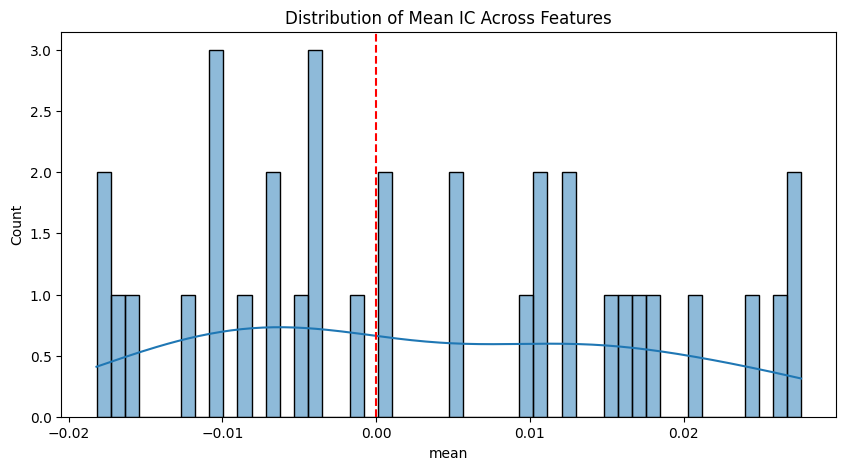

In [16]:
plt.figure(figsize=(10,5))
sns.histplot(ic_summary["mean"], bins=50, kde=True)
plt.axvline(0, color='red', linestyle='--')
plt.title("Distribution of Mean IC Across Features")
plt.show()

In [17]:
significant_features = ic_summary[ic_summary['t_stat'].abs() > 2.0]
print(f"Significant features: {len(significant_features)}")

Significant features: 23


In [ ]:
# Need enough cross-section each day
daily_counts = features_df.groupby('date').size()
print(f"Min stocks per day: {daily_counts.min()}")
print(f"Mean stocks per day: {daily_counts.mean()}")

Min stocks per day: 37
Mean stocks per day: 39.46695557963164


In [19]:
good_ir = ic_summary[ic_summary['IR'] > 0.3]
good_ir

,feature,mean,std,count,t_stat,IR


In [20]:
good_ir = ic_summary[ic_summary['IR'] > 0.1]
good_ir

,feature,mean,std,count,t_stat,IR


t-stat is high but IC IR is very low, so signal exits overall but not tradeable( requires more stocks to be considered)

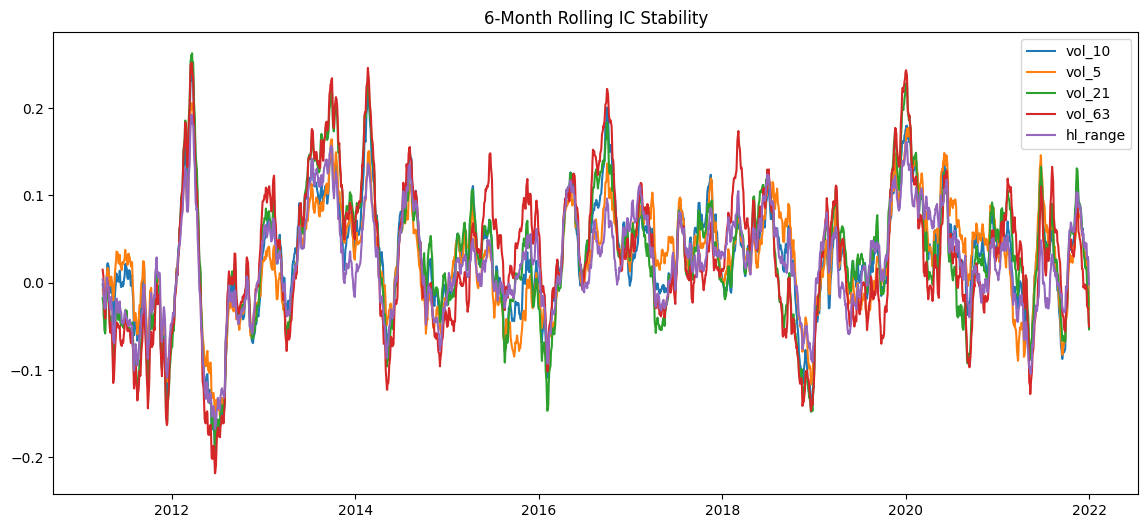

In [21]:
top_features = ic_summary.sort_values("t_stat", ascending=False).head(5)["feature"]

plt.figure(figsize=(14,6))

for feat in top_features:
    tmp = ic_df[ic_df["feature"] == feat]
    tmp = tmp.set_index("date")["ic"].rolling(63).mean()
    plt.plot(tmp, label=feat)

plt.legend()
plt.title("6-Month Rolling IC Stability")
plt.show()


Graph oscillates up and down for all, shows that the trend isn't consistent. Could be due to regime changes, mean reverting behaviour, weak signal etc

In [22]:
ic_summary.sort_values("t_stat", ascending=False).head(20)

,feature,mean,std,count,t_stat,IR
16,vol_10,0.027638,0.276673,2769,5.256460,0.099892
18,vol_5,0.024596,0.258240,2769,5.011944,0.095246
17,vol_21,0.026445,0.295626,2769,4.707264,0.089456
19,vol_63,0.027087,0.312613,2769,4.559482,0.086647
4,hl_range,0.020819,0.257480,2769,4.254799,0.080857
15,rev_5d,0.016885,0.233354,2769,3.807562,0.072358
14,rev_1d,0.015826,0.234857,2769,3.545916,0.067386
2,downside_vol_1d,0.017557,0.285499,2769,3.236018,0.061496
22,vol_avg_63,0.012590,0.212593,2769,3.116249,0.059220
3,downside_vol_5d,0.015319,0.269147,2769,2.995134,0.056919


In [23]:
ic_summary[ic_summary['t_stat']>=2].count()

feature    14
mean       14
std        14
count      14
t_stat     14
IR         14
dtype: int64

--------

Statistical Significance Testing of IC 

1) Building IC time series

This requires a wide-form table, not the long-form we currently have. Having wide-form makes it easier to plot,compute stats directly(now you need to do groupby everytime), ranking etc 

In [24]:
ic_df

,date,feature,ic
0,2011-01-03,dollar_volume,0.056899
1,2011-01-03,price_ma_ratio_5,0.306069
2,2011-01-03,price_ma_ratio_10,0.307492
3,2011-01-03,price_ma_ratio_21,0.206970
4,2011-01-03,price_ma_ratio_63,0.184211
...,...,...,...
94141,2021-12-31,dollar_vol_log,-0.210507
94142,2021-12-31,volume_trend,-0.140713
94143,2021-12-31,mom_x_vol_5,0.274859
94144,2021-12-31,mom_x_vol_21,0.292120


In [25]:
ic_ts = ic_df.pivot(index="date", columns="feature", values="ic")
ic_ts

feature,dollar_vol_log,dollar_volume,downside_vol_1d,downside_vol_5d,hl_range,mom_x_vol_21,mom_x_vol_5,mom_x_vol_63,pos_days_21,price_ma_ratio_10,price_ma_ratio_21,price_ma_ratio_252,price_ma_ratio_5,price_ma_ratio_63,rev_1d,rev_5d,vol_10,vol_21,vol_5,vol_63,vol_avg_21,vol_avg_5,vol_avg_63,vol_ratio_21_63,vol_ratio_5_21,volume_trend,z_price_21,z_price_63,z_return_1d_21,z_return_1d_35,z_return_1d_5,z_return_5d_21,z_return_5d_35,z_return_5d_5
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2011-01-03,0.056899,0.056899,0.321716,0.266240,0.406117,0.203888,0.292793,0.380749,0.141996,0.307492,0.206970,-0.029872,0.306069,0.184211,-0.353485,-0.197724,0.465149,0.355145,0.367236,0.524893,0.399478,0.363205,0.426505,-0.247748,-0.003319,-0.421053,0.245851,0.214320,0.243954,0.224751,0.263632,0.227122,0.163110,-0.083215
2011-01-04,-0.015647,-0.015647,0.309151,0.197487,0.270507,0.254623,0.191797,0.260076,0.156049,0.159317,0.158369,0.137743,0.184448,0.173542,-0.107634,-0.093883,0.356567,0.264580,0.253675,0.492176,0.320768,0.227359,0.291607,-0.307492,-0.073020,-0.305832,0.038170,0.060455,0.067330,0.045045,0.059981,0.146041,0.026790,-0.024893
2011-01-05,0.148886,0.148886,-0.036510,-0.064011,0.061404,0.198435,0.114509,0.253438,0.220021,0.103367,0.148412,-0.068990,0.118065,0.064248,0.049075,-0.084163,-0.131342,0.016596,-0.151494,0.224277,0.296349,0.227122,0.304884,-0.244192,-0.203651,-0.491702,0.052157,0.128497,-0.077762,-0.063774,-0.034851,0.012328,0.044808,0.071835
2011-01-06,0.183973,0.183973,0.147226,0.121147,0.006401,-0.032717,-0.046468,0.247037,0.031225,-0.033428,0.004267,0.194879,-0.076102,0.035088,-0.009246,0.012091,-0.016121,0.109768,-0.037933,0.215505,0.173542,0.126363,0.183025,-0.018729,-0.063063,-0.323376,-0.072072,-0.035088,-0.020389,0.003319,0.013988,-0.021574,-0.057610,-0.066856
2011-01-07,0.138928,0.138928,0.332148,0.306069,0.290185,0.085823,0.153390,0.390232,0.088216,0.034376,0.198435,0.326695,-0.059744,0.316027,0.092935,-0.140588,0.195827,0.330488,0.152916,0.460171,0.121859,0.030109,0.116880,-0.082504,-0.180654,-0.301328,0.006164,0.075865,-0.094595,-0.086534,-0.134898,0.004030,-0.059507,0.062115
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-12-27,-0.200188,-0.200188,-0.262477,-0.152720,-0.252158,-0.029831,-0.006191,-0.262477,0.126672,-0.207129,-0.091745,-0.418949,-0.205441,-0.259287,0.300188,0.219700,-0.425328,-0.412570,-0.257786,-0.313321,-0.018199,-0.074672,-0.004128,-0.243340,0.039587,-0.176923,-0.149531,-0.090432,-0.190056,-0.137148,-0.318762,-0.151782,0.010882,0.275985
2021-12-28,-0.208068,-0.208068,-0.266417,-0.137523,-0.271857,0.088743,0.020075,-0.189306,0.211955,-0.064916,-0.016323,-0.252908,0.008630,-0.179174,-0.387992,0.027017,-0.447280,-0.361538,-0.483490,-0.166792,-0.065291,-0.074109,-0.031707,-0.312195,-0.190244,0.115385,-0.017073,-0.025704,0.381426,0.385929,0.283865,0.097373,0.166604,0.419137
2021-12-29,-0.298499,-0.298499,-0.419137,-0.231520,-0.567917,0.194934,-0.063039,-0.210131,0.343312,-0.151032,0.048968,-0.344465,0.081989,-0.133021,-0.011257,0.223265,-0.492683,-0.525141,-0.629644,-0.300938,-0.014071,-0.046717,0.013696,-0.363790,-0.338086,-0.049906,0.082176,0.008255,-0.086116,0.021388,-0.124203,-0.254409,0.087805,0.142026


In [26]:
import statsmodels.api as sm

def newey_west_tstat(series, lags=5):
    
    y = series.dropna().values
    X = np.ones(len(y))   # intercept only

    model = sm.OLS(y, X)
    results = model.fit(cov_type='HAC', cov_kwds={'maxlags': lags})

    return results.tvalues[0], results.pvalues[0]


In [27]:
nw_results = []

for col in ic_ts.columns:
    t_stat, p_val = newey_west_tstat(ic_ts[col], lags=5)

    nw_results.append({
        "feature": col,
        "nw_t": t_stat,
        "nw_p": p_val
    })

nw_df = pd.DataFrame(nw_results)
nw_df


,feature,nw_t,nw_p
0,dollar_vol_log,-0.478524,0.632277
1,dollar_volume,-0.478524,0.632277
2,downside_vol_1d,1.767612,0.077126
3,downside_vol_5d,1.632336,0.102609
4,hl_range,2.530846,0.011379
5,mom_x_vol_21,1.366674,0.171728
6,mom_x_vol_5,-1.494309,0.135095
7,mom_x_vol_63,0.590736,0.554697
8,pos_days_21,0.085456,0.931899
9,price_ma_ratio_10,-2.365789,0.017992


In [28]:
nw_df[nw_df['nw_t']>=2].count()

feature    7
nw_t       7
nw_p       7
dtype: int64

Compared to the naive-tstat, now only 7/14 have newey-west t-stat value above 2. So we can move on with these more confidently sicne autocorr. and heteroskeadticity have been accounted for

--------

Bootstrap Significance Testing

In [29]:
def block_bootstrap(series, block = 20, n_samples = 5000):
    
    series = series.dropna().values
    n = len(series)
    means = []
    
    for _ in range(n_samples):
        
        idx = []
        
        while len(idx) < n:
            
            start = np.random.randint(0, n-block)
            idx.extend(range(start, start + block))

        sample = series[idx[:n]]
        means.append(sample.mean())

    return np.array(means)

In [30]:
boot_results = []

for col in ic_ts.columns:

    series = ic_ts[col].dropna()

    actual = series.mean()

    # Enforce null hypothesis: mean = 0
    shifted = series - actual

    dist = block_bootstrap(shifted, block=20, n_samples=3000)

    # Bootstrap distribution of mean under H0
    p_value = (np.abs(dist) >= np.abs(actual)).mean()

    boot_results.append({
        "feature": col,
        "boot_p": p_value
    })

boot_df = pd.DataFrame(boot_results)

In [31]:
boot_df

,feature,boot_p
0,dollar_vol_log,0.649667
1,dollar_volume,0.659000
2,downside_vol_1d,0.110667
3,downside_vol_5d,0.145333
4,hl_range,0.022000
5,mom_x_vol_21,0.186000
6,mom_x_vol_5,0.143667
7,mom_x_vol_63,0.568333
8,pos_days_21,0.934000
9,price_ma_ratio_10,0.026000


In [32]:
ic_stats_full = (
    ic_summary
    .merge(nw_df, on="feature")
    .merge(boot_df, on="feature")
)

In [33]:
ic_stats_full

,feature,mean,std,count,t_stat,IR,nw_t,nw_p,boot_p
0,dollar_vol_log,-0.003609,0.218123,2769,-0.870677,-0.016546,-0.478524,0.632277,0.649667
1,dollar_volume,-0.003609,0.218123,2769,-0.870677,-0.016546,-0.478524,0.632277,0.659000
2,downside_vol_1d,0.017557,0.285499,2769,3.236018,0.061496,1.767612,0.077126,0.110667
3,downside_vol_5d,0.015319,0.269147,2769,2.995134,0.056919,1.632336,0.102609,0.145333
4,hl_range,0.020819,0.257480,2769,4.254799,0.080857,2.530846,0.011379,0.022000
5,mom_x_vol_21,0.009903,0.224877,2769,2.317314,0.044038,1.366674,0.171728,0.186000
6,mom_x_vol_5,-0.010037,0.227501,2769,-2.321513,-0.044117,-1.494309,0.135095,0.143667
7,mom_x_vol_63,0.004928,0.241299,2769,1.074774,0.020425,0.590736,0.554697,0.568333
8,pos_days_21,0.000582,0.202812,2769,0.150916,0.002868,0.085456,0.931899,0.934000
9,price_ma_ratio_10,-0.017613,0.235132,2769,-3.941659,-0.074906,-2.365789,0.017992,0.026000


In [34]:
ic_stats_full.sort_values('t_stat', ascending=False)

,feature,mean,std,count,t_stat,IR,nw_t,nw_p,boot_p
16,vol_10,0.027638,0.276673,2769,5.256460,0.099892,2.864085,0.004182,0.010000
18,vol_5,0.024596,0.258240,2769,5.011944,0.095246,2.847084,0.004412,0.012000
17,vol_21,0.026445,0.295626,2769,4.707264,0.089456,2.540298,0.011076,0.024000
19,vol_63,0.027087,0.312613,2769,4.559482,0.086647,2.439246,0.014718,0.036667
4,hl_range,0.020819,0.257480,2769,4.254799,0.080857,2.530846,0.011379,0.022000
15,rev_5d,0.016885,0.233354,2769,3.807562,0.072358,2.388992,0.016895,0.023667
14,rev_1d,0.015826,0.234857,2769,3.545916,0.067386,3.635011,0.000278,0.000667
2,downside_vol_1d,0.017557,0.285499,2769,3.236018,0.061496,1.767612,0.077126,0.110667
22,vol_avg_63,0.012590,0.212593,2769,3.116249,0.059220,1.669751,0.094969,0.121000
3,downside_vol_5d,0.015319,0.269147,2769,2.995134,0.056919,1.632336,0.102609,0.145333


In [35]:
from config import PROCESSED_DATA_PATH
from pathlib import Path

def save_features(df):
    
    path = Path(PROCESSED_DATA_PATH) / "ic_df.parquet"
    df.to_parquet(path, index=False)
    print(f"Saved features to {path}")

save_features(ic_stats_full)

Saved features to /Users/sudhanvabharadwaj/Documents/Full_Quant_Pipeline/Data/processed/ic_df.parquet


Layer and What Is Filtered:

1) Mean IC - Useless signals
2) t-stat + IR - Noisy signals
3) Stability - Regime fragile
4) Newey-West - Autocorrelation illusions
5) Bootstrap - Luck-based artifacts

---------